# Physics-Informed Neural Network (PINN) for 1D Transient Heat Transfer

This notebook implements a foundational **Physics-Informed Neural Network (PINN)** to solve the 1D transient heat equation. The core objective is to predict the spatio-temporal temperature distribution without relying on labeled interior data, but rather by embedding the physical laws directly into the neural network's loss function.

### The Physics Problem
We solve the 1D Transient Heat Equation:
$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} $$

Where:
* $u(x,t)$ is the temperature.
* $x \in [-1, 1]$ is the spatial domain.
* $t \in [0, 1]$ is the temporal domain.
* $\alpha = 0.01$ is the thermal diffusivity.

**Boundary Conditions (BC) & Initial Conditions (IC):**
* IC: $u(x,0) = -\sin(\pi x)$ (Initial temperature distribution)
* BC: $u(-1,t) = 0$ and $u(1,t) = 0$ (Ends are kept at zero temperature)

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.12.1+cpu


### 1. Neural Network Architecture
We use a Multi-Layer Perceptron (MLP) with 2 input features $(x, t)$ and 1 output $(u)$. 
Crucially, we use the `Tanh` activation function. Unlike `ReLU`, `Tanh` is continuously differentiable, which is mandatory for computing the second-order spatial derivatives $(\frac{\partial^2 u}{\partial x^2})$ required by the PDE.

In [14]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

### 2. Physics Embedding via Automatic Differentiation
This is the core of the PINN. Instead of using a traditional data-driven Mean Squared Error (MSE) loss, we use `torch.autograd` to analytically compute the gradients of the network's output with respect to its inputs. 

The physical residual $f = u_t - \alpha u_{xx}$ is added to the loss function, forcing the neural network to strictly obey the thermodynamic laws.

In [15]:
def pde_loss(model, x, t, alpha=0.01):
    # Enable gradient tracking for spatial and temporal coordinates
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    # Network prediction
    u = model(x, t)
    
    # First-order derivatives (Automatic Differentiation)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    # Second-order spatial derivative
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    # PDE Residual
    pde_residual = u_t - alpha * u_xx
    
    return torch.mean(pde_residual**2)

### 3. Collocation Points Generation
We sample points randomly across the spatio-temporal domain.
* **$N_{PDE}$**: Points inside the domain where the physics loss is enforced.
* **$N_{BC}$**: Points on the spatial boundaries.
* **$N_{IC}$**: Points at time $t=0$.

In [16]:
N_pde = 5000 
N_bc = 500    
N_ic = 500    

# Interior Points
x_pde = torch.empty(N_pde, 1).uniform_(-1, 1)
t_pde = torch.empty(N_pde, 1).uniform_(0, 1)

# Initial Conditions (t=0)
x_ic = torch.empty(N_ic, 1).uniform_(-1, 1)
t_ic = torch.zeros(N_ic, 1)
u_ic_true = -torch.sin(np.pi * x_ic)

# Boundary Conditions (x=-1 and x=1)
t_bc = torch.empty(N_bc, 1).uniform_(0, 1)
x_bc_left = -torch.ones(N_bc // 2, 1)
x_bc_right = torch.ones(N_bc // 2, 1)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
u_bc_true = torch.zeros(N_bc, 1)

### 4. Model Training
We train the model using the Adam optimizer. The total loss is a composite function:
$Loss_{Total} = Loss_{PDE} + Loss_{IC} + Loss_{BC}$

In [17]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 3000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Evaluate losses
    loss_pde = pde_loss(model, x_pde, t_pde)
    loss_ic = torch.mean((model(x_ic, t_ic) - u_ic_true)**2)
    loss_bc = torch.mean((model(x_bc, t_bc) - u_bc_true)**2)
    
    # Backpropagation
    loss = loss_pde + loss_ic + loss_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {loss.item():.5f} | PDE: {loss_pde.item():.5f} | IC: {loss_ic.item():.5f} | BC: {loss_bc.item():.5f}")

print("Training completed successfully!")

Epoch    0 | Total Loss: 0.51214 | PDE: 0.00027 | IC: 0.49299 | BC: 0.01889
Epoch  500 | Total Loss: 0.00040 | PDE: 0.00024 | IC: 0.00008 | BC: 0.00008
Epoch 1000 | Total Loss: 0.00012 | PDE: 0.00010 | IC: 0.00001 | BC: 0.00001
Epoch 1500 | Total Loss: 0.00006 | PDE: 0.00005 | IC: 0.00000 | BC: 0.00001
Epoch 2000 | Total Loss: 0.00004 | PDE: 0.00004 | IC: 0.00000 | BC: 0.00000
Epoch 2500 | Total Loss: 0.00003 | PDE: 0.00003 | IC: 0.00000 | BC: 0.00000
Training completed successfully!


### 5. Validation and Visualization
We generate a mesh grid over the entire domain to visualize the predicted heat flow field.

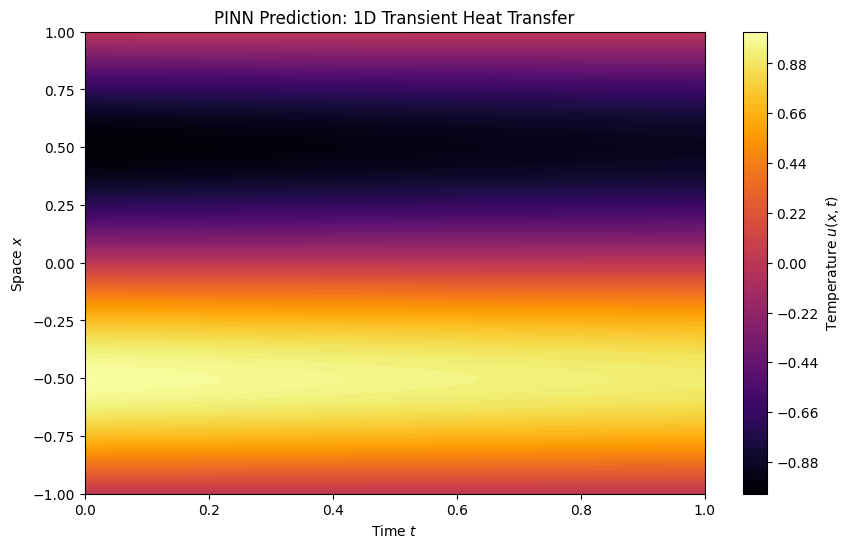

In [22]:
x_test = torch.linspace(-1, 1, 100).view(-1, 1)
t_test = torch.linspace(0, 1, 100).view(-1, 1)
X, T = torch.meshgrid(x_test.squeeze(), t_test.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

with torch.no_grad():
    U_pred = model(X_flat, T_flat).reshape(100, 100)

plt.figure(figsize=(10, 6))
plt.contourf(T, X, U_pred, 100, cmap='inferno')
plt.colorbar(label='Temperature $u(x,t)$')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')
plt.title('PINN Prediction: 1D Transient Heat Transfer')
plt.savefig('pinn_heat_transfer.png', dpi=300, bbox_inches='tight')
plt.show()